In [2]:
import pandas as pd
import mne
import pyxdf
import numpy as np
import re
import matplotlib.pyplot as plt
from mne.report import Report
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from pathlib import Path

## Parameters
Pick task and participants first, then load XDF + annotations.

In [3]:
base_data_dir = Path(".")

task = "2-back"  # options: 0-back, 2-back, 2-back_dual
participants = ["P002"]


task_eeg_dir = base_data_dir / task / "eeg"
print("Task EEG directory:", task_eeg_dir.resolve())

Task EEG directory: C:\Users\n.saleem\Documents\GitHub\0x2x2dual_WCST_analysis\data\2-back\eeg


In [4]:
def normalize_pid(pid):
    pid = str(pid).upper().strip()
    if pid.startswith("SUB-"):
        pid = pid.replace("SUB-", "")
    if not pid.startswith("P"):
        pid = f"P{int(pid):03d}"
    return pid


def find_input_files(task_dir, selected_participants=None, patterns=None):
    patterns = patterns or ["*_eeg.xdf", "*_raw.fif", "*_annot_raw.fif"]

    all_files = []
    for pat in patterns:
        all_files.extend(task_dir.rglob(pat))
    all_files = sorted(set(all_files))

    if not selected_participants:
        return all_files

    selected = {normalize_pid(pid) for pid in selected_participants}
    filtered = []
    for path in all_files:
        m = re.search(r"sub-(P\d+)", str(path), flags=re.IGNORECASE)
        if not m:
            continue
        pid = normalize_pid(m.group(1))
        if pid in selected:
            filtered.append(path)
    return filtered


input_files = find_input_files(task_eeg_dir, participants)
print(f"Found {len(input_files)} matching input file(s)")
for p in input_files:
    print(" -", p)

Found 1 matching input file(s)
 - 2-back\eeg\sub-P002\ses-S001\eeg\sub-P001_ses-S001_task-Default_run-001_eeg.xdf


In [5]:
ch_electrodes = {
    "Ch1": "P7", "Ch2": "P4", "Ch3": "Cz", "Ch4": "Pz", "Ch5": "P3",
    "Ch6": "P8", "Ch7": "O1", "Ch8": "O2", "Ch9": "T8", "Ch10": "F8",
    "Ch11": "C4", "Ch12": "F4", "Ch13": "Fp2", "Ch14": "Fz", "Ch15": "C3",
    "Ch16": "F3", "Ch17": "Fp1", "Ch18": "T7", "Ch19": "F7", "Ch20": "EXT"
}
default_ch_names = list(ch_electrodes.keys())


def stream_name(stream):
    info = stream.get("info", {})
    name = info.get("name", [""])[0]
    stype = info.get("type", [""])[0]
    return (name or stype or "unnamed_stream").strip()


def load_streams_as_dict(xdf_path):
    streams, _ = pyxdf.load_xdf(str(xdf_path))
    stream_dict = {}
    for i, stream in enumerate(streams):
        base = stream_name(stream)
        key = re.sub(r"\W+", "_", base).strip("_") or f"stream_{i}"
        if key in stream_dict:
            key = f"{key}_{i}"
        stream_dict[key] = stream
    return stream_dict


def pick_eeg_stream(stream_dict):
    best_key = None
    best_score = -1
    for key, stream in stream_dict.items():
        info = stream.get("info", {})
        stype = str(info.get("type", [""])[0]).lower()
        sname = str(info.get("name", [""])[0]).lower()
        n_ch = int(float(info.get("channel_count", [0])[0]))
        srate = float(info.get("nominal_srate", [0])[0])

        score = 0
        if stype == "eeg":
            score += 3
        if "eeg" in sname:
            score += 2
        if n_ch >= 8:
            score += 1
        if srate > 0:
            score += 1

        if score > best_score:
            best_score = score
            best_key = key

    if best_key is None:
        raise ValueError("No EEG-like stream found in XDF")
    return best_key, stream_dict[best_key]


def create_raw_from_eeg_stream(eeg_stream):
    eeg_data = np.asarray(eeg_stream["time_series"], dtype=float).T * 1e-6
    sfreq = float(eeg_stream["info"]["nominal_srate"][0])

    if eeg_data.shape[0] != len(default_ch_names):
        raise ValueError(f"Expected {len(default_ch_names)} channels, got {eeg_data.shape[0]}")

    info = mne.create_info(ch_names=default_ch_names, sfreq=sfreq, ch_types="eeg")
    raw = mne.io.RawArray(eeg_data, info, first_samp=0)
    raw.rename_channels(ch_electrodes)

    montage = mne.channels.make_standard_montage("standard_1020")
    raw.rename_channels({"EXT": "EOG"})
    raw.set_channel_types({"EOG": "eog"})
    raw.set_montage(montage, on_missing="ignore")
    return raw

In [6]:
def _marker_text(value):
    arr = np.asarray(value).squeeze()
    if arr.size == 0:
        return "marker"
    if arr.ndim == 0:
        return str(arr.item())
    return "|".join(str(x) for x in arr.tolist())


def add_markers_from_all_streams(raw, stream_dict, eeg_key):
    eeg_stream = stream_dict[eeg_key]
    eeg_t0 = float(eeg_stream["time_stamps"][0])

    onsets = []
    durations = []
    descriptions = []

    for key, stream in stream_dict.items():
        if key == eeg_key:
            continue

        stamps = np.asarray(stream.get("time_stamps", []), dtype=float)
        if stamps.size == 0:
            continue

        series = stream.get("time_series", [])
        name = stream_name(stream)

        for i, stamp in enumerate(stamps):
            onset = stamp - eeg_t0
            if onset < 0 or onset > raw.times[-1]:
                continue

            marker_val = series[i] if i < len(series) else "marker"
            onsets.append(float(onset))
            durations.append(0.0)
            descriptions.append(f"{name}: {_marker_text(marker_val)}")

    annotations = mne.Annotations(onset=onsets, duration=durations, description=descriptions)
    raw.set_annotations(annotations)
    return raw


def load_raw_with_markers(xdf_path):
    stream_dict = load_streams_as_dict(xdf_path)
    eeg_key, eeg_stream = pick_eeg_stream(stream_dict)
    raw = create_raw_from_eeg_stream(eeg_stream)
    raw = add_markers_from_all_streams(raw, stream_dict, eeg_key)

    stream_overview = []
    for key, stream in stream_dict.items():
        info = stream.get("info", {})
        stream_overview.append({
            "stream_key": key,
            "name": info.get("name", [""])[0],
            "type": info.get("type", [""])[0],
            "n_channels": int(float(info.get("channel_count", [0])[0])),
            "nominal_srate": float(info.get("nominal_srate", [0])[0]),
            "n_samples": len(stream.get("time_stamps", [])),
        })

    return raw, stream_dict, pd.DataFrame(stream_overview)

In [7]:
raw_by_file = {}
stream_tables = {}

for input_path in input_files:
    try:
        suffix = input_path.suffix.lower()

        if suffix == ".xdf":
            raw, streams_dict, stream_table = load_raw_with_markers(input_path)
        elif suffix == ".fif":
            raw = mne.io.read_raw_fif(input_path, preload=True)
            streams_dict = {}
            stream_table = pd.DataFrame([
                {
                    "stream_key": "fif_input",
                    "name": input_path.name,
                    "type": "FIF",
                    "n_channels": raw.info["nchan"],
                    "nominal_srate": raw.info["sfreq"],
                    "n_samples": raw.n_times,
                }
            ])
        else:
            raise ValueError(f"Unsupported file extension: {suffix}")

        raw_by_file[str(input_path)] = raw
        stream_tables[str(input_path)] = stream_table
        print(f"Loaded: {input_path.name} | channels={raw.info['nchan']} | annotations={len(raw.annotations)}")

    except Exception as exc:
        print(f"Failed: {input_path.name} -> {exc}")

print("\nLoaded files:", len(raw_by_file))

Creating RawArray with float64 data, n_channels=20, n_times=1033970
    Range : 0 ... 1033969 =      0.000 ...  2067.938 secs
Ready.
Loaded: sub-P001_ses-S001_task-Default_run-001_eeg.xdf | channels=20 | annotations=212

Loaded files: 1


Preview file: 2-back\eeg\sub-P002\ses-S001\eeg\sub-P001_ses-S001_task-Default_run-001_eeg.xdf


,stream_key,name,type,n_channels,nominal_srate,n_samples
0,NIC2_EEG_EEG,NIC2-EEG-EEG,EEG,20,500.0,1033970
1,LSL_server,LSL_server,Markers,1,0.0,212


Using matplotlib as 2D backend.


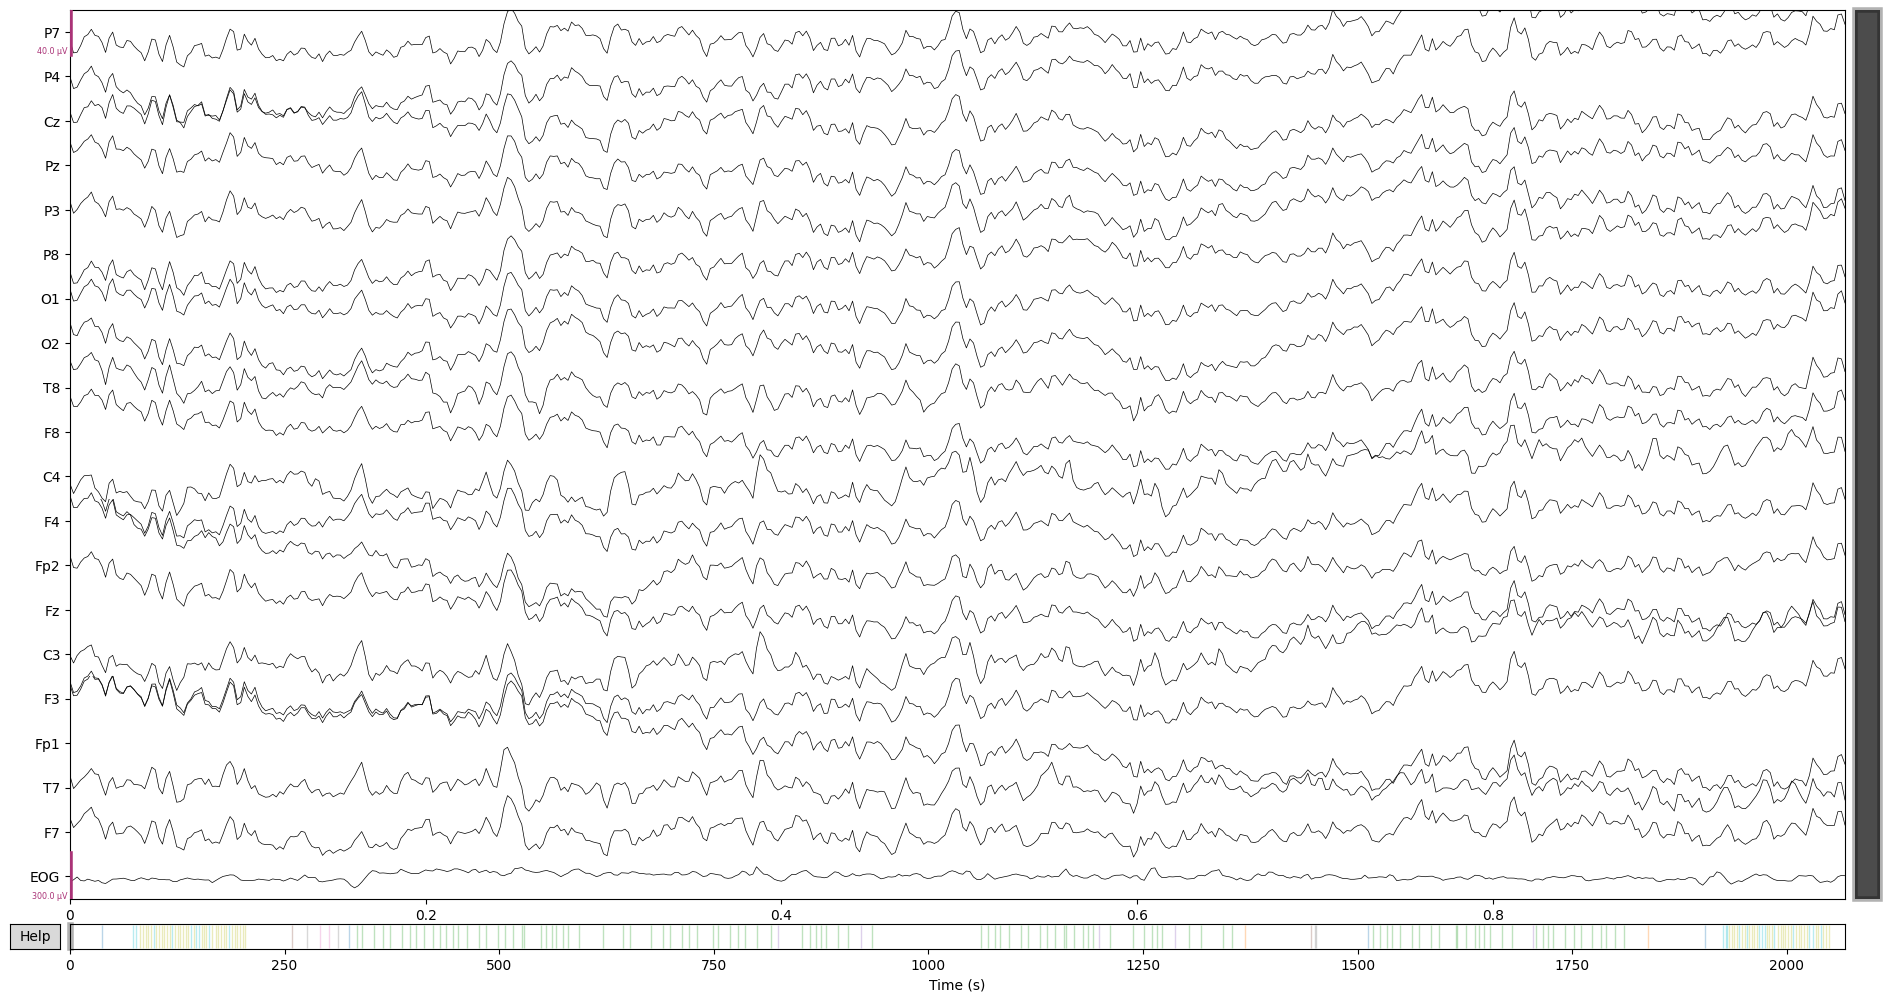

In [8]:
if raw_by_file:
    first_key = next(iter(raw_by_file))
    print("Preview file:", first_key)
    display(stream_tables[first_key])
    raw_by_file[first_key].plot(duration=1)
else:
    print("No file loaded.")

## Breaks, Categories, Export
Add automatic break annotations, categorize markers, then save annotated FIF files.

In [9]:
break_gap_sec = 8.0
export_suffix = "_annot_raw.fif"


def categorize_description(desc):
    text = str(desc).strip()
    low = text.lower()

    # Keep auto break labels unchanged
    if low.startswith("break/auto"):
        return text

    marker_text = text.split(":", 1)[-1].strip() if ":" in text else text
    marker_low = marker_text.lower()

    break_words = ["break", "pause", "rest"]
    if any(word in marker_low for word in break_words):
        return f"BREAK/MARKER::{marker_text}"

    return f"TASK/EVENT::{marker_text}"


def relabel_annotations(raw):
    ann = raw.annotations
    new_desc = [categorize_description(d) for d in ann.description]
    raw.set_annotations(mne.Annotations(onset=ann.onset, duration=ann.duration, description=new_desc))
    return raw


def add_auto_breaks(raw, min_gap_sec=8.0):
    ann = raw.annotations

    # Remove previously auto-added breaks to make reruns deterministic
    keep_idx = [i for i, d in enumerate(ann.description) if not str(d).startswith("BREAK/AUTO")]
    ann_base = mne.Annotations(
        onset=ann.onset[keep_idx],
        duration=ann.duration[keep_idx],
        description=[ann.description[i] for i in keep_idx],
    )

    event_onsets = np.array(ann_base.onset, dtype=float)
    if event_onsets.size < 2:
        raw.set_annotations(ann_base)
        return raw

    order = np.argsort(event_onsets)
    sorted_onsets = event_onsets[order]

    auto_onsets = []
    auto_durations = []
    auto_desc = []

    for i in range(len(sorted_onsets) - 1):
        current_onset = sorted_onsets[i]
        next_onset = sorted_onsets[i + 1]
        gap = next_onset - current_onset
        if gap >= min_gap_sec:
            auto_onsets.append(current_onset)
            auto_durations.append(gap)
            auto_desc.append(f"BREAK/AUTO::{gap:.1f}s")

    auto_ann = mne.Annotations(onset=auto_onsets, duration=auto_durations, description=auto_desc)
    raw.set_annotations(ann_base + auto_ann)
    return raw

In [10]:
processed_raw_by_file = {}
category_rows = []

for file_key, raw in raw_by_file.items():
    r = raw.copy()
    r = relabel_annotations(r)
    r = add_auto_breaks(r, min_gap_sec=break_gap_sec)
    processed_raw_by_file[file_key] = r

    desc_series = pd.Series(r.annotations.description)
    category_rows.append({
        "file": file_key,
        "n_annotations": len(r.annotations),
        "n_task_events": int(desc_series.str.startswith("TASK/EVENT").sum()),
        "n_break_marker": int(desc_series.str.startswith("BREAK/MARKER").sum()),
        "n_break_auto": int(desc_series.str.startswith("BREAK/AUTO").sum()),
    })

pd.DataFrame(category_rows)

,file,n_annotations,n_task_events,n_break_marker,n_break_auto
0,2-back\eeg\sub-P002\ses-S001\eeg\sub-P001_ses-...,303,212,0,91


In [11]:
export_rows = []
for file_key, raw in processed_raw_by_file.items():
    xdf_path = Path(file_key)
    fif_path = xdf_path.with_name(f"{xdf_path.stem}{export_suffix}")
    raw.save(fif_path, overwrite=True)
    export_rows.append({
        "xdf": str(xdf_path),
        "fif": str(fif_path),
        "n_channels": raw.info["nchan"],
        "sfreq": raw.info["sfreq"],
        "n_annotations": len(raw.annotations),
    })

pd.DataFrame(export_rows)

Writing c:\Users\n.saleem\Documents\GitHub\0x2x2dual_WCST_analysis\data\2-back\eeg\sub-P002\ses-S001\eeg\sub-P001_ses-S001_task-Default_run-001_eeg_annot_raw.fif
Closing c:\Users\n.saleem\Documents\GitHub\0x2x2dual_WCST_analysis\data\2-back\eeg\sub-P002\ses-S001\eeg\sub-P001_ses-S001_task-Default_run-001_eeg_annot_raw.fif
[done]


,xdf,fif,n_channels,sfreq,n_annotations
0,2-back\eeg\sub-P002\ses-S001\eeg\sub-P001_ses-...,2-back\eeg\sub-P002\ses-S001\eeg\sub-P001_ses-...,20,500.0,303


Preview processed annotations from: 2-back\eeg\sub-P002\ses-S001\eeg\sub-P001_ses-S001_task-Default_run-001_eeg.xdf


TASK/EVENT::PSYCHOPY.2_BACK.TEST.SPACE.CORRECT    109
TASK/EVENT::WINCONSIN_CORRECT                      62
TASK/EVENT::WINCONSIN_FALSE                        22
BREAK/AUTO::9.9s                                    7
BREAK/AUTO::14.0s                                   5
BREAK/AUTO::13.9s                                   5
BREAK/AUTO::8.1s                                    5
TASK/EVENT::PSYCHOPY.2_BACK.TEST.SPACE.FALSE        5
BREAK/AUTO::10.0s                                   4
BREAK/AUTO::10.1s                                   4
BREAK/AUTO::14.1s                                   4
TASK/EVENT::PSYCHOPY.2_BACK.TRAIN.SPACE.FALSE       4
BREAK/AUTO::8.2s                                    4
BREAK/AUTO::14.2s                                   3
BREAK/AUTO::8.3s                                    3
BREAK/AUTO::10.2s                                   3
TASK/EVENT::WINCONSIN_INIT_LSL                      2
TASK/EVENT::PSYCHOPY.2_BACK.TRAIN.BEGIN             2
BREAK/AUTO::9.6s            

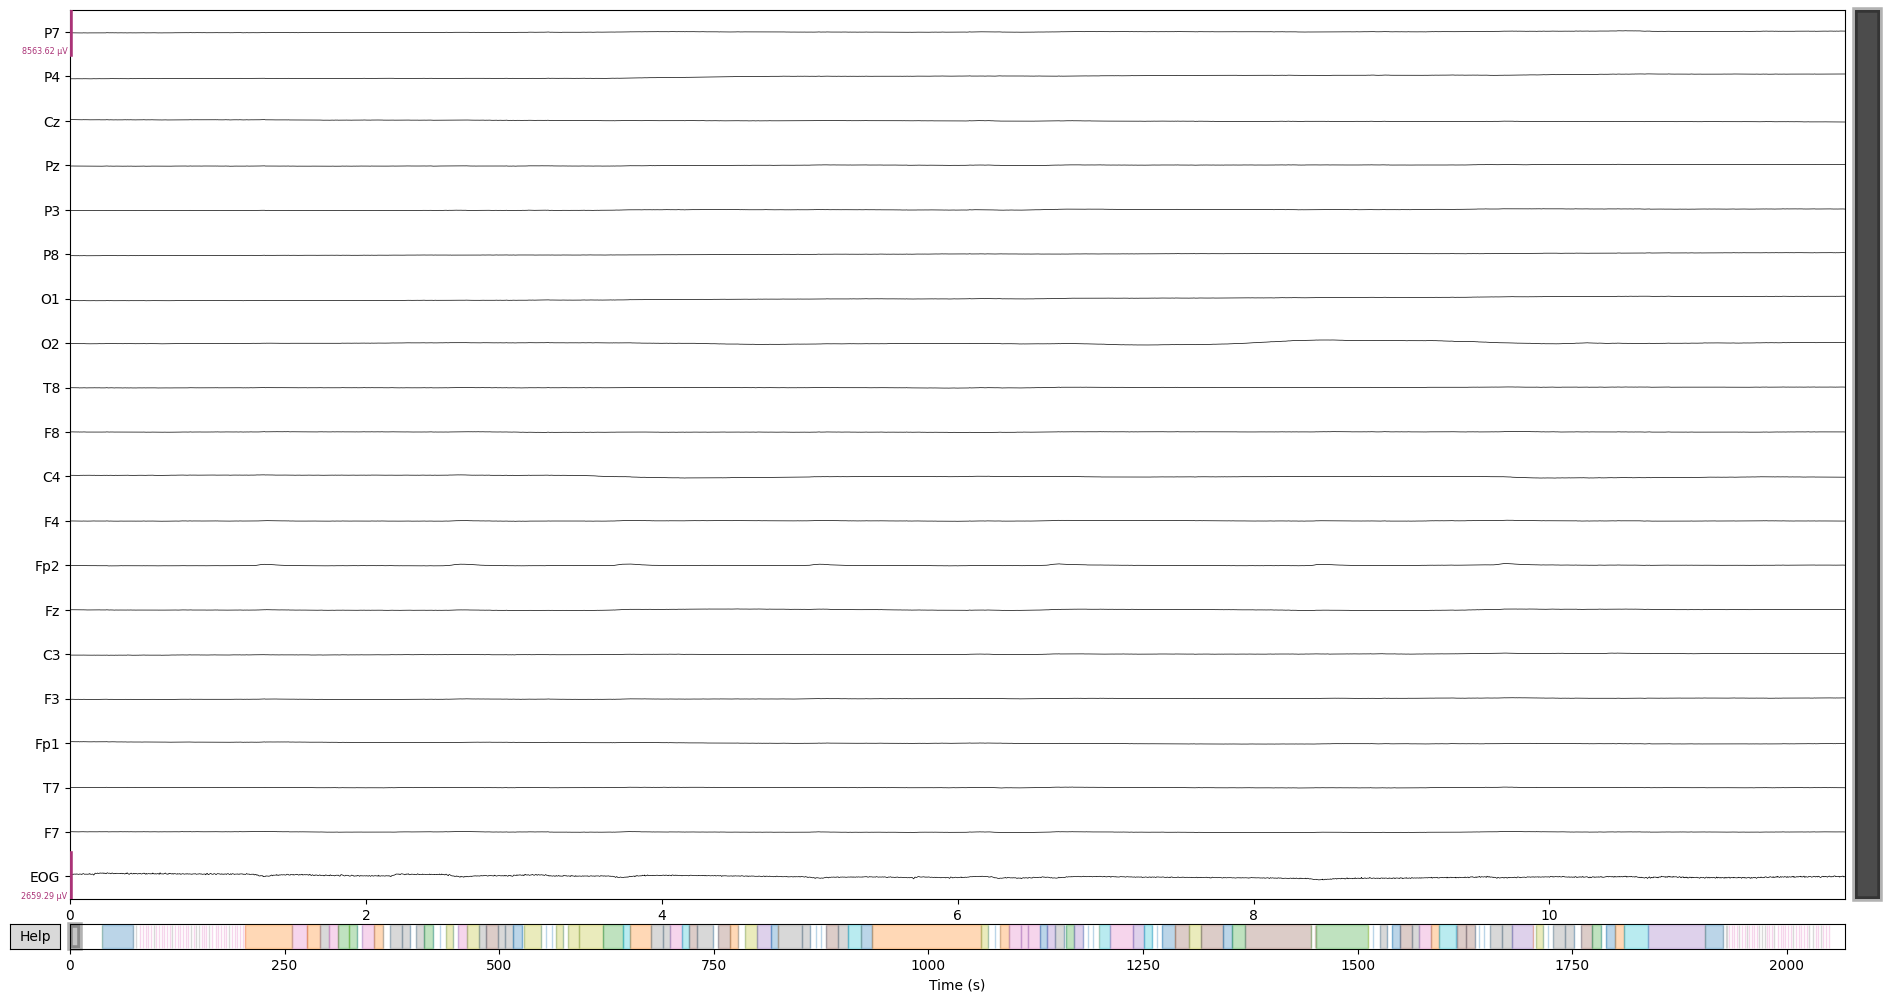

In [ ]:
if processed_raw_by_file:
    k = next(iter(processed_raw_by_file))
    print("Preview processed annotations from:", k)
    display(pd.Series(processed_raw_by_file[k].annotations.description).value_counts().head(20))
    processed_raw_by_file[k].plot(duration=12, scalings="auto")
else:
    print("No processed raws available.")